# Step 5 - Fine-tuning the COCO model on Cityscapes

**Objective.** The EoMT model trained on COCO is not specialised on road scenes. Here it is fine-tuned on the Cityscapes training set for semantic segmentation, and its improvement is measured on the validation set using the same evaluation pipeline as Step 4.

**Data and approach.** Cityscapes train/val. Fine-tuning is done in two stages: first the prediction head only (backbone frozen), then a full fine-tune with a lower backbone learning rate. Mixed precision (AMP) is used to speed up training, and metrics are logged to Weights & Biases.

**Output.** A per-class and overall mIoU comparison between three models: the original COCO checkpoint, the fine-tuned version, and the provided Cityscapes checkpoint.

## 1 - Setup: Drive, paths and weights

_Mounts Drive and defines the paths: the starting COCO weights and the output files of the fine-tuned models (phase 1 and phase 2)._

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Update this path if your files are elsewhere in your Drive
PROJECT_DIR = '/content/drive/MyDrive/project/datasets'
EOMT_COCO_WEIGHTS = f'{PROJECT_DIR}/eomt_coco.bin'
EOMT_CITYSCAPES_WEIGHTS = f'{PROJECT_DIR}/eomt_cityscapes.bin'

# Verify these archive names match your Drive
CITYSCAPES_GT_ZIP = f'{PROJECT_DIR}/gtFine_trainvaltest.zip'
CITYSCAPES_IMG_ZIP = f'{PROJECT_DIR}/leftImg8bit_trainvaltest.zip'

FINETUNED_WEIGHTS = f'{PROJECT_DIR}/eomt_coco_finetuned_cityscapes.bin'
FULL_FINETUNED_WEIGHTS = f'{PROJECT_DIR}/eomt_coco_full_finetuned_cityscapes.bin'
print("Paths set successfully!")

Mounted at /content/drive
Paths set successfully!


## 2 - Extracting the Cityscapes training set

_Extracts the training images and annotations needed for fine-tuning._

In [3]:
import os
os.makedirs('/content/datasets/cityscapes', exist_ok=True)

if not os.path.exists(CITYSCAPES_GT_ZIP) or not os.path.exists(CITYSCAPES_IMG_ZIP):
    raise FileNotFoundError("Cannot find the zip files! Please check the paths in Cell 1.")

print("1. Unzipping Ground Truth labels...")
!unzip -qo {CITYSCAPES_GT_ZIP} -d /content/datasets/cityscapes/

print("2. Copying and unzipping images locally...")
!cp {CITYSCAPES_IMG_ZIP} /content/leftImg8bit_tmp.zip
!unzip -qo /content/leftImg8bit_tmp.zip -d /content/datasets/cityscapes/
!rm -f /content/leftImg8bit_tmp.zip

n_train_imgs = !find /content/datasets/cityscapes/leftImg8bit/train -name "*.png" | wc -l
print(f"Found {n_train_imgs[0]} train images. Data ready!")

1. Unzipping Ground Truth labels...
2. Copying and unzipping images locally...
Found 2975 train images. ✅ Data ready!


## 3 - Installation, repo clone and restart

_Installs the torch stack and the EoMT dependencies, clones the repo and restarts the runtime at the end: the restart is needed because torch is reinstalled from scratch._

In [ ]:
import os

print("Step 1: Reinstalling torch stack...")
!pip uninstall -y torch torchvision torchaudio torchtext 2>/dev/null || true
!pip install -q --default-timeout=300 --retries=10 \
    torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 \
    --index-url https://download.pytorch.org/whl/cu126

print("Step 2: Installing other dependencies...")
!pip install -q --default-timeout=300 --retries=10 \
    lightning torchmetrics pyyaml transformers timm einops \
    scipy opencv-python pillow matplotlib tqdm cityscapesscripts

print("Step 3: Cloning repo...")
if not os.path.exists('/content/MaskArchitectureAnomaly_CourseProject'):
    !git clone https://github.com/LeoPasseri34/MaskArchitectureAnomaly_CourseProject.git
else:
    print("   Repo already exists, skipping clone.")

%cd /content/MaskArchitectureAnomaly_CourseProject/eomt

print("Step 4: Installing eomt requirements...")
!pip install -q -r requirements.txt

print("\n" + "=" * 60)
print("Installation complete. Restarting runtime now...")
print("=" * 60)
os.kill(os.getpid(), 9)

Step 1: Reinstalling torch stack...
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 218.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 214.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 233.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 58.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 57.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 81.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 146.2 M

### Post-restart check

_Verifies that torch, lightning, torchmetrics and CUDA are loaded correctly after the restart._

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt

try:
    import torch, lightning, torchmetrics, yaml, torchvision
    print(f"torch       {torch.__version__}")
    print(f"torchvision {torchvision.__version__}")
    print(f"lightning   {lightning.__version__}")
    print(f"torchmetrics {torchmetrics.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   Device: {torch.cuda.get_device_name(0)}")
    import torchvision.ops
    print("torchvision.ops loaded OK")
except RuntimeError as e:
    print(f"{e}")

/content/MaskArchitectureAnomaly_CourseProject/eomt
torch       2.7.0+cu126
torchvision 0.22.0+cu126
lightning   2.5.1.post0
torchmetrics 1.7.1
CUDA available: True
   Device: Tesla T4
torchvision.ops loaded OK


## 4 - Building the EoMT model

_Defines `build_eomt_model()` with the option to override the number of classes (here 19, the Cityscapes classes)._

In [ ]:
import yaml
import importlib
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DINOV2_NUM_SPECIAL_TOKENS = 1 + 4
PATCH_SIZE = 16

def instantiate_base_model(config, config_path, img_size, num_classes_override=None):
    """Helper to instantiate the model with a given image size and optional class count override."""
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=img_size, **encoder_cfg.get("init_args", {}))

    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    if num_classes_override is not None:
        num_classes = num_classes_override
    else:
        num_classes = 19 if "cityscapes" in config_path else 133

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "data" in config and "init_args" in config["data"] and "stuff_classes" in config["data"]["init_args"]:
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = lit_cls(
        img_size=img_size,
        num_classes=num_classes,
        network=network,
        **model_kwargs,
    ).to(device)

    return model


def build_eomt_model(config_path, weights_path, num_classes_override=None):
    """Instantiates model and handles pos_embed mismatches automatically."""
    print(f"\n--- Loading: {config_path} ---")
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    img_size = config.get("model", {}).get("init_args", {}).get("img_size", (640, 640))
    if isinstance(img_size, int):
        img_size = (img_size, img_size)

    model = instantiate_base_model(config, config_path, img_size, num_classes_override)
    state_dict = torch.load(weights_path, map_location=device, weights_only=True)

    # Drop class_head and criterion weights from the checkpoint
    if num_classes_override is not None:
        state_dict = {k: v for k, v in state_dict.items()
                      if "class_head" not in k and "criterion" not in k}
        print(f"   Dropped class_head and criterion from checkpoint (adapting to {num_classes_override} classes)")

    try:
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        if missing:
            print(f"   Missing keys: {len(missing)} (expected if class head replaced)")
        if unexpected:
            print(f"   Unexpected keys: {len(unexpected)}")
        print("Loaded weights on first try!")
    except RuntimeError as e:
        if "pos_embed" in str(e):
            print("Pos embedding mismatch. Adapting to checkpoint resolution...")
            ckpt_seq_len = state_dict['network.encoder.backbone.pos_embed'].shape[1]
            num_patches = ckpt_seq_len - DINOV2_NUM_SPECIAL_TOKENS
            grid_side = int(round(np.sqrt(num_patches)))
            assert grid_side * grid_side == num_patches
            true_resolution = grid_side * PATCH_SIZE
            new_img_size = (true_resolution, true_resolution)
            print(f" Re-instantiating at resolution {new_img_size}")

            model = instantiate_base_model(config, config_path, new_img_size, num_classes_override)
            missing, unexpected = model.load_state_dict(state_dict, strict=False)
            print(f"   After resize - Missing: {len(missing)}, Unexpected: {len(unexpected)}")
        else:
            raise e

    return model, config

print("Model builder compiled!")

Using device: cuda
Model builder compiled!


## 5 - Loading the starting weights

_Builds the 19-class model and injects the weights to resume training from. This is a checkpoint-loading cell: it lets training continue from an intermediate checkpoint instead of retraining from scratch._

In [ ]:
import torch

COCO_CONFIG = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"

print("1. Building raw model architecture (19 classes)...")
model, config = build_eomt_model(
    COCO_CONFIG,
    EOMT_COCO_WEIGHTS,
    num_classes_override=19
)

print(f"\n2.Injecting 63% Phase 2 weights from {FULL_FINETUNED_WEIGHTS}...")
finetuned_state = torch.load(FULL_FINETUNED_WEIGHTS, map_location=device, weights_only=True)
model.load_state_dict(finetuned_state, strict=False)

model.train()
print(f"Perfect Fine-Tuned Model ready. num_classes={model.num_classes}")

1. Building raw model architecture (19 classes)...

--- Loading: configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


   Dropped class_head and criterion from checkpoint (adapting to 19 classes)
   Missing keys: 3 (expected if class head replaced)
Loaded weights on first try!

2.Injecting 63% Phase 2 weights from /content/drive/MyDrive/Polito_FAIMLDL_project/eomt_coco_full_finetuned_cityscapes.bin...
Perfect Fine-Tuned Model ready. num_classes=19


## 6 - Cityscapes dataset for fine-tuning

_Custom `Dataset` class: it reads images and labels, remaps the raw IDs to the 19 train-ids, and applies data augmentation (horizontal flip, random scaling, crop) only in training._

In [ ]:
import os
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import random

RAW_TO_TRAIN_ID = np.full(256, 255, dtype=np.int64)
for raw, trn in [(7,0),(8,1),(11,2),(12,3),(13,4),(17,5),(19,6),(20,7),(21,8),(22,9),(23,10),(24,11),(25,12),(26,13),(27,14),(28,15),(31,16),(32,17),(33,18)]:
    RAW_TO_TRAIN_ID[raw] = trn

class CityscapesSemantic(Dataset):
    def __init__(self, root, split="train", crop_size=(640, 640), augment=True):
        self.root = root
        self.split = split
        self.crop_size = crop_size
        self.augment = augment and (split == "train")
        img_dir = os.path.join(root, "leftImg8bit", split)
        gt_dir  = os.path.join(root, "gtFine", split)

        self.samples = []
        for city in sorted(os.listdir(img_dir)):
            city_img_dir = os.path.join(img_dir, city)
            city_gt_dir  = os.path.join(gt_dir, city)
            if not os.path.isdir(city_img_dir): continue
            for fname in sorted(os.listdir(city_img_dir)):
                if not fname.endswith("_leftImg8bit.png"): continue
                img_path = os.path.join(city_img_dir, fname)
                gt_path  = os.path.join(city_gt_dir, fname.replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                if os.path.exists(gt_path): self.samples.append((img_path, gt_path))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, gt_path = self.samples[idx]
        img, gt = Image.open(img_path).convert("RGB"), Image.open(gt_path)

        if self.augment:
            if random.random() < 0.5: img, gt = TF.hflip(img), TF.hflip(gt)
            scale = random.uniform(0.5, 2.0)
            new_w, new_h = int(img.size[0] * scale), int(img.size[1] * scale)
            img = TF.resize(img, [new_h, new_w], interpolation=TF.InterpolationMode.BILINEAR)
            gt  = TF.resize(gt,  [new_h, new_w], interpolation=TF.InterpolationMode.NEAREST)
            ch, cw = self.crop_size
            if new_h < ch or new_w < cw:
                pad_h, pad_w = max(0, ch - new_h), max(0, cw - new_w)
                img = TF.pad(img, [0, 0, pad_w, pad_h], fill=0)
                gt  = TF.pad(gt,  [0, 0, pad_w, pad_h], fill=255)
                new_h, new_w = max(new_h, ch), max(new_w, cw)
            top, left = random.randint(0, new_h - ch), random.randint(0, new_w - cw)
            img, gt = TF.crop(img, top, left, ch, cw), TF.crop(gt,  top, left, ch, cw)

        # Keep the raw 0-255 tensor: do not apply to_tensor() or normalize
        img = torch.from_numpy(np.array(img)).permute(2, 0, 1).float()
        gt = torch.from_numpy(RAW_TO_TRAIN_ID[np.array(gt)]).long()
        return img, gt

def collate_fn(batch):
    imgs, targets = [b[0] for b in batch], [b[1] for b in batch]
    if len(set(tuple(i.shape) for i in imgs)) == 1:
        imgs, targets = torch.stack(imgs), torch.stack(targets)
    return imgs, targets

ROOT = "/content/datasets/cityscapes"
train_loader = DataLoader(CityscapesSemantic(ROOT, split="train", augment=True), batch_size=2, shuffle=True, num_workers=2, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(CityscapesSemantic(ROOT, split="val", augment=False), batch_size=1, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_fn)
print(f"Data loaders ready.")

Data loaders ready.


## 7 - Inference and mIoU functions

_Defines the semantic prediction (with a safe resize to 640x640 to avoid GPU out-of-memory) and `evaluate_miou()`, which computes the per-class IoU on the validation set._

In [ ]:
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
import numpy as np

def get_semantic_prediction(model, tensor_img):
    model.eval()
    if tensor_img.dim() == 3: tensor_img = tensor_img.unsqueeze(0)

    orig_shape = tensor_img.shape[-2:]

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        # Shrink large val images to safe 640x640 to prevent OOM
        img_resized = F.interpolate(tensor_img.to(device), size=(640, 640), mode="bilinear", align_corners=False)

        mask_logits_per_layer, class_logits_per_layer = model(img_resized)
        ml, cl = mask_logits_per_layer[-1], class_logits_per_layer[-1]

        # Expand masks back to native Cityscapes resolution (1024x2048)
        ml = F.interpolate(ml, orig_shape, mode="bilinear", align_corners=False)
        logits = model.to_per_pixel_logits_semantic(ml, cl)[0]

        preds = logits[:19, :, :].argmax(0)
        return preds.detach().cpu().numpy().astype(np.uint8)

def evaluate_miou(model, loader, max_batches=None):
    from torchmetrics.classification import MulticlassJaccardIndex
    from tqdm import tqdm
    metric = MulticlassJaccardIndex(num_classes=19, ignore_index=255, average=None).to(device)
    model.eval()

    with torch.no_grad():
        for i, (imgs, targets) in enumerate(tqdm(loader, desc="Validating")):
            if max_batches and i >= max_batches: break

            # Safely extract the single item whether it is a list or a tensor
            img = imgs[0] if isinstance(imgs, (list, tuple)) else imgs[0]
            gt  = targets[0] if isinstance(targets, (list, tuple)) else targets[0]

            pred_np = get_semantic_prediction(model, img)
            pred_t = torch.as_tensor(pred_np, dtype=torch.long, device=device)

            # Force target into strict 2D shape [H, W] to match predictions
            target_t = gt.clone().detach().squeeze()

            # Update metric with explicit [1, H, W] shapes
            metric.update(pred_t.unsqueeze(0), target_t.to(device).unsqueeze(0))

    iou = metric.compute().cpu().numpy()
    return iou, np.nanmean(iou)

CITYSCAPES_CLASSES = {
    0: "road", 1: "sidewalk", 2: "building", 3: "wall", 4: "fence",
    5: "pole", 6: "traffic light", 7: "traffic sign", 8: "vegetation",
    9: "terrain", 10: "sky", 11: "person", 12: "rider", 13: "car",
    14: "truck", 15: "bus", 16: "train", 17: "motorcycle", 18: "bicycle"
}

print("Bulletproof inference helpers ready.")

Bulletproof inference helpers ready.


## 8 - Fine-tuning, phase 1: prediction head only

_Freezes the backbone and trains only the prediction head. This is the lightweight starting experiment suggested by the project. AMP (mixed precision) is used to reduce training time._

In [ ]:
import torch.nn.functional as F
from torch.amp.grad_scaler import GradScaler
from torch.amp.autocast_mode import autocast
from torch.optim.lr_scheduler import LambdaLR
import torch
import math

# --- CONFIG ---
TOTAL_STEPS   = 20000
WARMUP_STEPS  = 1000
VAL_EVERY     = 500
LR_HEAD       = 5e-5
LR_BACKBONE   = 1e-5
WEIGHT_DECAY  = 0.05
STRATEGY      = "head_only"  # Freezes backbone, trains only the head

# --- Training parameters ---
START_STEP = 10000
best_miou = 0.5975  # Update this if your exact best score before the crash was slightly different
global_step = START_STEP

print(f"Applying Strategy: {STRATEGY}")
for name, param in model.named_parameters():
    param.requires_grad = True if ("class_head" in name or "mask_head" in name or "queries" in name) else False

head_params, backbone_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad: continue
    if "class_head" in name or "mask_head" in name or "queries" in name: head_params.append(param)
    else: backbone_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": head_params, "lr": LR_HEAD},
    {"params": backbone_params, "lr": LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)

# Cosine decay schedule with linear warmup
scheduler = LambdaLR(optimizer, lambda s: (s + START_STEP)/WARMUP_STEPS if (s + START_STEP) < WARMUP_STEPS else 0.5*(1+math.cos(math.pi*((s + START_STEP)-WARMUP_STEPS)/(TOTAL_STEPS-WARMUP_STEPS))))
scaler = GradScaler()

def compute_loss_simple(model, imgs, targets):
    # DIRECT FORWARD PASS
    mask_logits_per_layer, class_logits_per_layer = model(imgs)
    total_loss = 0.0
    n_layers = len(mask_logits_per_layer)

    for ml, cl in zip(mask_logits_per_layer, class_logits_per_layer):
        ml = F.interpolate(ml, size=(640, 640), mode="bilinear", align_corners=False)
        logits = model.to_per_pixel_logits_semantic(ml, cl)

        for i in range(len(imgs)):
            logit = logits[i]
            tgt = targets[i].to(device)
            loss = F.cross_entropy(logit[None, :19], tgt[None], ignore_index=255)
            total_loss += loss / (n_layers * len(imgs))

    return total_loss

print(f"\nResuming training from step {global_step}...")
train_iter = iter(train_loader)
model.train()



while global_step < TOTAL_STEPS:
    try: imgs, targets = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        imgs, targets = next(train_iter)

    if isinstance(imgs, list): imgs = torch.stack(imgs)
    if isinstance(targets, list): targets = torch.stack(targets)

    imgs, targets = imgs.to(device), targets.to(device)

    optimizer.zero_grad(set_to_none=True)
    with autocast(dtype=torch.float16, device_type="cuda"):
        loss = compute_loss_simple(model, imgs, targets)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    global_step += 1
    if global_step % 50 == 0:
        print(f"Step {global_step}/{TOTAL_STEPS} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if global_step % VAL_EVERY == 0:
        print(f"\n--- Validating at step {global_step} ---")
        iou_per_class, miou = evaluate_miou(model, val_loader, max_batches=50)
        print(f"  Validation mIoU: {miou*100:.2f}%")
        if miou > best_miou:
            best_miou = miou
            torch.save(model.state_dict(), FINETUNED_WEIGHTS)
            print(f"   Saved new best checkpoint (mIoU {miou*100:.2f}%) to {FINETUNED_WEIGHTS}")
        model.train()

print(f"\nFine-tuning complete. Final Best mIoU: {best_miou*100:.2f}%")

Applying Strategy: head_only

🚀 Resuming training from step 10000...
Step 10050/20000 | Loss: 0.9498 | LR: 2.69e-05
Step 10100/20000 | Loss: 0.1271 | LR: 2.67e-05
Step 10150/20000 | Loss: 0.1491 | LR: 2.64e-05
Step 10200/20000 | Loss: 0.7111 | LR: 2.62e-05
Step 10250/20000 | Loss: 0.4576 | LR: 2.60e-05
Step 10300/20000 | Loss: 0.2208 | LR: 2.58e-05
Step 10350/20000 | Loss: 0.3340 | LR: 2.56e-05
Step 10400/20000 | Loss: 0.2507 | LR: 2.54e-05
Step 10450/20000 | Loss: 0.1619 | LR: 2.52e-05
Step 10500/20000 | Loss: 0.2149 | LR: 2.50e-05

--- Validating at step 10500 ---


Validating:  10%|█         | 50/500 [00:11<01:46,  4.22it/s]


  Validation mIoU: 59.34%
Step 10550/20000 | Loss: 0.3391 | LR: 2.48e-05
Step 10600/20000 | Loss: 0.0754 | LR: 2.46e-05
Step 10650/20000 | Loss: 0.1929 | LR: 2.44e-05
Step 10700/20000 | Loss: 0.1246 | LR: 2.42e-05
Step 10750/20000 | Loss: 0.1292 | LR: 2.40e-05
Step 10800/20000 | Loss: 0.1306 | LR: 2.38e-05
Step 10850/20000 | Loss: 0.0892 | LR: 2.36e-05
Step 10900/20000 | Loss: 0.0429 | LR: 2.33e-05
Step 10950/20000 | Loss: 0.1192 | LR: 2.31e-05
Step 11000/20000 | Loss: 0.1325 | LR: 2.29e-05

--- Validating at step 11000 ---


Validating:  10%|█         | 50/500 [00:11<01:43,  4.37it/s]


  Validation mIoU: 60.13%
  💾 Saved new best checkpoint (mIoU 60.13%) to /content/drive/MyDrive/progetto_FAIDML/eomt_coco_finetuned_cityscapes.bin
Step 11050/20000 | Loss: 0.2237 | LR: 2.27e-05
Step 11100/20000 | Loss: 0.0470 | LR: 2.25e-05
Step 11150/20000 | Loss: 0.0909 | LR: 2.23e-05
Step 11200/20000 | Loss: 0.2446 | LR: 2.21e-05
Step 11250/20000 | Loss: 0.2435 | LR: 2.19e-05
Step 11300/20000 | Loss: 0.2810 | LR: 2.17e-05
Step 11350/20000 | Loss: 0.0860 | LR: 2.15e-05
Step 11400/20000 | Loss: 0.2334 | LR: 2.13e-05
Step 11450/20000 | Loss: 0.4765 | LR: 2.11e-05
Step 11500/20000 | Loss: 0.0929 | LR: 2.09e-05

--- Validating at step 11500 ---


...

  Validation mIoU: 59.60%
Step 19050/20000 | Loss: 0.2034 | LR: 3.08e-07
Step 19100/20000 | Loss: 0.0321 | LR: 2.76e-07
Step 19150/20000 | Loss: 0.0864 | LR: 2.47e-07
Step 19200/20000 | Loss: 0.1063 | LR: 2.18e-07
Step 19250/20000 | Loss: 0.0635 | LR: 1.92e-07
Step 19300/20000 | Loss: 1.2773 | LR: 1.67e-07
Step 19350/20000 | Loss: 0.2674 | LR: 1.44e-07
Step 19400/20000 | Loss: 0.2328 | LR: 1.23e-07
Step 19450/20000 | Loss: 0.1561 | LR: 1.03e-07
Step 19500/20000 | Loss: 0.1951 | LR: 8.54e-08

--- Validating at step 19500 ---


Validating:  10%|█         | 50/500 [00:11<01:41,  4.42it/s]


  Validation mIoU: 59.60%
Step 19550/20000 | Loss: 0.1075 | LR: 6.92e-08
Step 19600/20000 | Loss: 0.1688 | LR: 5.47e-08
Step 19650/20000 | Loss: 0.0901 | LR: 4.19e-08
Step 19700/20000 | Loss: 0.1401 | LR: 3.08e-08
Step 19750/20000 | Loss: 0.3406 | LR: 2.14e-08
Step 19800/20000 | Loss: 0.1169 | LR: 1.37e-08
Step 19850/20000 | Loss: 0.1415 | LR: 7.69e-09
Step 19900/20000 | Loss: 0.1632 | LR: 3.42e-09
Step 19950/20000 | Loss: 0.0949 | LR: 8.54e-10
Step 20000/20000 | Loss: 0.0389 | LR: 0.00e+00

--- Validating at step 20000 ---


Validating:  10%|█         | 50/500 [00:11<01:44,  4.30it/s]

  Validation mIoU: 59.58%

✅ Fine-tuning complete. Final Best mIoU: 60.26%


### Installing Weights & Biases

_Installs W&B for logging metrics during training._

In [ ]:
!pip install -q --upgrade wandb

### Weights & Biases login

_Authenticates to W&B. The API key is requested at runtime with `getpass`, so it is never written into the notebook or pushed to GitHub._

In [ ]:
import wandb
from getpass import getpass

# The API key must NOT be hardcoded in the notebook (it would leak to GitHub).
# It is requested at runtime and never stored in the .ipynb file.
wandb.login(key=getpass('Paste your W&B API key (input is hidden): '))


## 9 - Fine-tuning, phase 2: full fine-tune

_Unfreezes the whole model and continues training with a lower learning rate on the backbone, logging metrics to W&B._

In [ ]:
import torch.nn.functional as F
from torch.amp.grad_scaler import GradScaler
from torch.amp.autocast_mode import autocast
from torch.optim.lr_scheduler import LambdaLR
import torch
import math
import wandb

# --- Phase 2 training config ---
WANDB_RUN_ID  = "s9d2s9tu"                  # Connected to your active session
START_STEP    = 18500
best_miou     = 0.6987                      # best score achieved
global_step   = START_STEP

TOTAL_STEPS   = 20000
WARMUP_STEPS  = 1000
VAL_EVERY     = 500
LR_HEAD       = 5e-5
LR_BACKBONE   = 5e-6
WEIGHT_DECAY  = 0.05
STRATEGY      = "full_finetune"

print(f"Applying Strategy: {STRATEGY} (Resuming from {START_STEP})")

# Ensure the entire architecture is unlocked for optimization
for name, param in model.named_parameters():
    param.requires_grad = True

head_params, backbone_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad: continue
    if "class_head" in name or "mask_head" in name or "queries" in name: head_params.append(param)
    else: backbone_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": head_params, "lr": LR_HEAD},
    {"params": backbone_params, "lr": LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)

# Cosine decay schedule with linear warmup
scheduler = LambdaLR(optimizer, lambda s: (s + START_STEP)/WARMUP_STEPS if (s + START_STEP) < WARMUP_STEPS else 0.5*(1+math.cos(math.pi*((s + START_STEP)-WARMUP_STEPS)/(TOTAL_STEPS-WARMUP_STEPS))))
scaler = GradScaler()

# --- Initialize W&B logging ---
wandb.init(
    project="FAIMLDL_Cityscapes",
    id=WANDB_RUN_ID,
    resume="must"
)

def compute_loss_simple(model, imgs, targets):
    mask_logits_per_layer, class_logits_per_layer = model(imgs)
    total_loss = 0.0
    n_layers = len(mask_logits_per_layer)

    for ml, cl in zip(mask_logits_per_layer, class_logits_per_layer):
        ml = F.interpolate(ml, size=(640, 640), mode="bilinear", align_corners=False)
        logits = model.to_per_pixel_logits_semantic(ml, cl)

        for i in range(len(imgs)):
            logit = logits[i]
            tgt = targets[i].to(device)
            loss = F.cross_entropy(logit[None, :19], tgt[None], ignore_index=255)
            total_loss += loss / (n_layers * len(imgs))

    return total_loss

print(f"\nResuming {TOTAL_STEPS}-step Full Fine-Tune...")
train_iter = iter(train_loader)
model.train()

while global_step < TOTAL_STEPS:
    try: imgs, targets = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        imgs, targets = next(train_iter)

    if isinstance(imgs, list): imgs = torch.stack(imgs)
    if isinstance(targets, list): targets = torch.stack(targets)

    imgs, targets = imgs.to(device), targets.to(device)

    optimizer.zero_grad(set_to_none=True)
    with autocast(dtype=torch.float16, device_type="cuda"):
        loss = compute_loss_simple(model, imgs, targets)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    global_step += 1
    if global_step % 50 == 0:
        print(f"Step {global_step}/{TOTAL_STEPS} | Loss: {loss.item():.4f} | LR Head: {optimizer.param_groups[0]['lr']:.2e}")

        wandb.log({
            "train/loss": loss.item(),
            "train/lr_head": optimizer.param_groups[0]['lr'],
            "train/lr_backbone": optimizer.param_groups[1]['lr'],
            "global_step": global_step
        })

    if global_step % VAL_EVERY == 0:
        print(f"\n--- Validating at step {global_step} ---")
        iou_per_class, miou = evaluate_miou(model, val_loader, max_batches=50)
        print(f"  Validation mIoU: {miou*100:.2f}%")

        wandb.log({
            "val/mIoU": miou * 100,
            "global_step": global_step
        })

        if miou > best_miou:
            best_miou = miou
            torch.save(model.state_dict(), FULL_FINETUNED_WEIGHTS)
            print(f"   Saved new best FULL checkpoint (mIoU {miou*100:.2f}%) to {FULL_FINETUNED_WEIGHTS}")
        model.train()

wandb.finish()
print(f"\nFull Fine-tuning complete. Final Best mIoU: {best_miou*100:.2f}%")

Applying Strategy: full_finetune (Resuming from 18500)



🚀 Resuming 20000-step Full Fine-Tune...
Step 18550/20000 | Loss: 0.1210 | LR Head: 7.15e-07
Step 18600/20000 | Loss: 0.0624 | LR Head: 6.67e-07
Step 18650/20000 | Loss: 0.0589 | LR Head: 6.20e-07
Step 18700/20000 | Loss: 0.1192 | LR Head: 5.75e-07
Step 18750/20000 | Loss: 0.0607 | LR Head: 5.32e-07
Step 18800/20000 | Loss: 0.0168 | LR Head: 4.91e-07
Step 18850/20000 | Loss: 0.0705 | LR Head: 4.51e-07
Step 18900/20000 | Loss: 0.0914 | LR Head: 4.12e-07
Step 18950/20000 | Loss: 0.0975 | LR Head: 3.76e-07
Step 19000/20000 | Loss: 0.0922 | LR Head: 3.41e-07

--- Validating at step 19000 ---


Validating:  10%|█         | 50/500 [00:10<01:37,  4.64it/s]


  Validation mIoU: 69.98%
  💾 Saved new best FULL checkpoint (mIoU 69.98%) to /content/drive/MyDrive/Polito_FAIMLDL_project/eomt_coco_full_finetuned_cityscapes.bin
Step 19050/20000 | Loss: 0.9655 | LR Head: 3.08e-07
Step 19100/20000 | Loss: 0.0991 | LR Head: 2.76e-07
Step 19150/20000 | Loss: 0.0473 | LR Head: 2.47e-07
Step 19200/20000 | Loss: 0.0738 | LR Head: 2.18e-07
Step 19250/20000 | Loss: 0.1288 | LR Head: 1.92e-07
Step 19300/20000 | Loss: 0.0634 | LR Head: 1.67e-07
Step 19350/20000 | Loss: 0.0466 | LR Head: 1.44e-07
Step 19400/20000 | Loss: 0.3371 | LR Head: 1.23e-07
Step 19450/20000 | Loss: 0.1212 | LR Head: 1.03e-07
Step 19500/20000 | Loss: 0.1166 | LR Head: 8.54e-08

--- Validating at step 19500 ---


Validating:  10%|█         | 50/500 [00:12<01:55,  3.91it/s]


  Validation mIoU: 70.01%
  💾 Saved new best FULL checkpoint (mIoU 70.01%) to /content/drive/MyDrive/Polito_FAIMLDL_project/eomt_coco_full_finetuned_cityscapes.bin
Step 19550/20000 | Loss: 0.0487 | LR Head: 6.92e-08
Step 19600/20000 | Loss: 0.1090 | LR Head: 5.47e-08
Step 19650/20000 | Loss: 0.1126 | LR Head: 4.19e-08
Step 19700/20000 | Loss: 0.1179 | LR Head: 3.08e-08
Step 19750/20000 | Loss: 0.0464 | LR Head: 2.14e-08
Step 19800/20000 | Loss: 0.0583 | LR Head: 1.37e-08
Step 19850/20000 | Loss: 0.1171 | LR Head: 7.69e-09
Step 19900/20000 | Loss: 0.1426 | LR Head: 3.42e-09
Step 19950/20000 | Loss: 0.1109 | LR Head: 8.54e-10
Step 20000/20000 | Loss: 0.0052 | LR Head: 0.00e+00

--- Validating at step 20000 ---


Validating:  10%|█         | 50/500 [00:11<01:47,  4.18it/s]


  Validation mIoU: 70.01%
  💾 Saved new best FULL checkpoint (mIoU 70.01%) to /content/drive/MyDrive/Polito_FAIMLDL_project/eomt_coco_full_finetuned_cityscapes.bin


global_step,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇████
train/loss,▂▁▁▂▁▁▁▂▂▂█▂▁▂▂▁▁▃▂▂▁▂▂▂▁▁▂▂▂▁
train/lr_backbone,██▇▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/lr_head,██▇▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/mIoU,▁▇█
global_step,20000
train/loss,0.00516
train/lr_backbone,0
train/lr_head,0
val/mIoU,70.0103



✅ Full Fine-tuning complete. Final Best mIoU: 70.01%


## 10 - Qualitative inference

_Visualises some predictions of the fine-tuned model on the validation set, using the official Cityscapes palette._

🎨 Generating visual predictions...


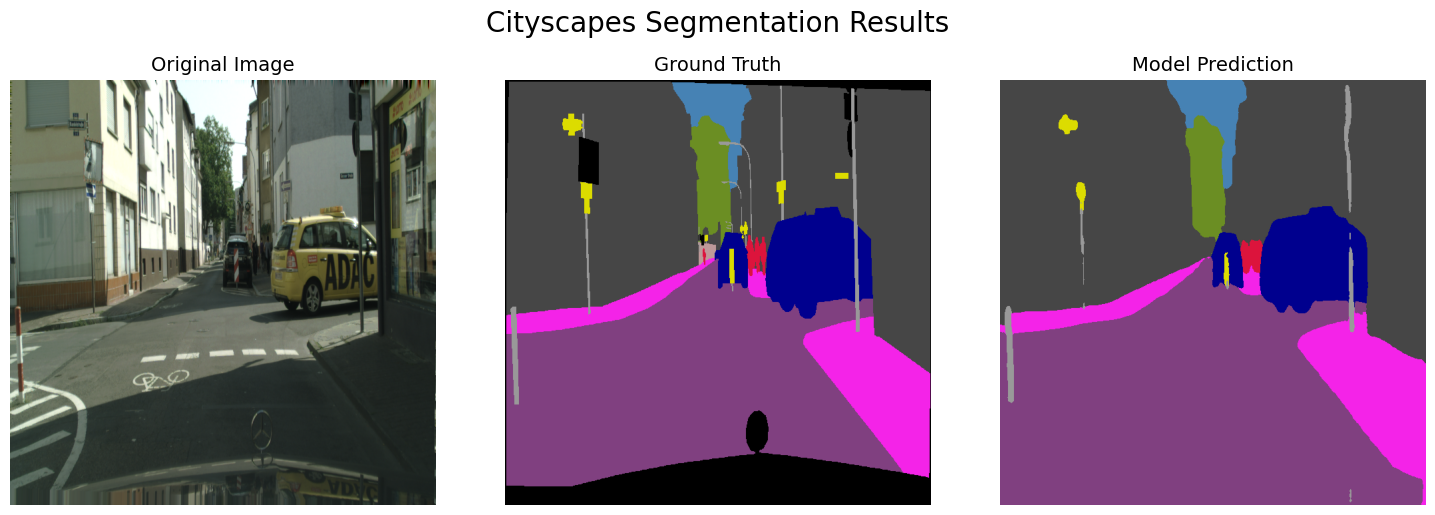

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Official Cityscapes color map
CITYSCAPES_COLORS = np.array([
    [128, 64, 128],  # 0: road
    [244, 35, 232],  # 1: sidewalk
    [70, 70, 70],    # 2: building
    [102, 102, 156], # 3: wall
    [190, 153, 153], # 4: fence
    [153, 153, 153], # 5: pole
    [250, 170, 30],  # 6: traffic light
    [220, 220, 0],   # 7: traffic sign
    [107, 142, 35],  # 8: vegetation
    [152, 251, 152], # 9: terrain
    [70, 130, 180],  # 10: sky
    [220, 20, 60],   # 11: person
    [255, 0, 0],     # 12: rider
    [0, 0, 142],     # 13: car
    [0, 0, 70],      # 14: truck
    [0, 60, 100],    # 15: bus
    [0, 80, 100],    # 16: train
    [0, 0, 230],     # 17: motorcycle
    [119, 11, 32],   # 18: bicycle
    [0, 0, 0]        # 255: ignore (Black)
])

def map_predictions_to_colors(mask_tensor):
    """Converts a 2D tensor of class IDs into a 3D RGB image array."""
    mask = mask_tensor.cpu().numpy()
    mask[mask == 255] = 19
    color_mask = CITYSCAPES_COLORS[mask]
    return color_mask.astype(np.uint8)

def visualize_predictions(model, dataloader, num_images=3):
    print("Generating visual predictions...")
    model.eval()

    # Grab one batch of validation data
    iterator = iter(dataloader)
    imgs, targets = next(iterator)

    if isinstance(imgs, list): imgs = torch.stack(imgs)
    if isinstance(targets, list): targets = torch.stack(targets)

    # Prevent empty axes if the batch size is smaller than num_images
    actual_num = min(num_images, len(imgs))

    imgs = imgs.to(device)
    targets = targets.to(device)

    # Resize images and targets to 640x640
    imgs_resized = F.interpolate(imgs, size=(640, 640), mode="bilinear", align_corners=False)
    targets = targets.unsqueeze(1).float()
    targets = F.interpolate(targets, size=(640, 640), mode="nearest").squeeze(1).long()

    # Run the model (no gradients needed)
    with torch.no_grad():
        with torch.amp.autocast(dtype=torch.float16, device_type="cuda"):
            mask_logits_per_layer, class_logits_per_layer = model(imgs_resized)

            ml = mask_logits_per_layer[-1]
            cl = class_logits_per_layer[-1]

            ml = F.interpolate(ml, size=(640, 640), mode="bilinear", align_corners=False)
            logits = model.to_per_pixel_logits_semantic(ml, cl)
            predictions = logits.argmax(dim=1)

    # Plotting dynamically based on batch size
    fig, axes = plt.subplots(actual_num, 3, figsize=(15, 5 * actual_num))
    if actual_num == 1:
        axes = np.expand_dims(axes, axis=0) # Safety catch for batch size 1

    fig.suptitle("Cityscapes Segmentation Results", fontsize=20, y=1.02)

    for i in range(actual_num):
        # 1. Prepare Original Image (Foolproof Min-Max Scaling)
        img_raw = imgs_resized[i].cpu().float().permute(1, 2, 0).numpy()
        img_min = img_raw.min()
        img_max = img_raw.max()
        # Force the tensor strictly into a 0.0 - 1.0 range so matplotlib doesn't turn it white
        img_display = (img_raw - img_min) / (img_max - img_min + 1e-8)

        # 2. Prepare Masks
        gt_color = map_predictions_to_colors(targets[i])
        pred_color = map_predictions_to_colors(predictions[i])

        # Draw Original
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title("Original Image", fontsize=14)
        axes[i, 0].axis('off')

        # Draw Ground Truth
        axes[i, 1].imshow(gt_color)
        axes[i, 1].set_title("Ground Truth", fontsize=14)
        axes[i, 1].axis('off')

        # Draw Prediction
        axes[i, 2].imshow(pred_color)
        axes[i, 2].set_title("Model Prediction", fontsize=14)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()
    model.train()

# RUN THE VISUALIZATION
visualize_predictions(model, val_loader, num_images=3)

## 11 - Per-class evaluation of the fine-tuned model

_Computes the IoU of each of the 19 classes and the overall mIoU on the validation set, in a sorted table._

In [ ]:
import pandas as pd
import torch

# The 19 training classes of Cityscapes
CITYSCAPES_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]

print("Running full per-class evaluation...")
model.eval()

# Assuming your evaluate_miou function takes max_batches.
# We set it to a high number (or remove it if your function allows) to evaluate the whole validation set.
iou_per_class, final_miou = evaluate_miou(model, val_loader, max_batches=1000)

# Format into a pandas DataFrame
results = []
for i, iou in enumerate(iou_per_class):
    results.append({
        "Class": CITYSCAPES_CLASSES[i].capitalize(),
        "IoU Score (%)": round(iou * 100, 2)
    })

df_results = pd.DataFrame(results)

print(f"\nFinal Overall Mean IoU: {final_miou*100:.2f}%\n")
print("-" * 35)
print(df_results.to_string(index=False))
print("-" * 35)

model.train()

# ── Save evaluation results so visualisations can be re-run without
#    repeating the training pipeline ────────────────────────────────────────
import json as _json, os as _os

_results_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs"
_os.makedirs(_results_dir, exist_ok=True)
_save_path = _os.path.join(_results_dir, "step5_eval_results.json")
_payload = {
    "iou_per_class": [float(v) for v in iou_per_class],
    "final_miou":    float(final_miou),
}
with open(_save_path, "w") as _f:
    _json.dump(_payload, _f, indent=2)
print(f"\n\U0001f4be Evaluation results saved → {_save_path}")


📊 Running full per-class evaluation...


Validating: 100%|██████████| 500/500 [01:35<00:00,  5.22it/s]


🏆 Final Overall Mean IoU: 70.39%

-----------------------------------
        Class  IoU Score (%)
         Road      98.059998
     Sidewalk      84.529999
     Building      90.449997
         Wall      63.860001
        Fence      59.830002
         Pole      43.779999
Traffic light      54.020000
 Traffic sign      63.970001
   Vegetation      89.989998
      Terrain      68.800003
          Sky      93.239998
       Person      68.570000
        Rider      36.759998
          Car      91.989998
        Truck      74.889999
          Bus      73.019997
        Train      67.320000
   Motorcycle      47.799999
      Bicycle      66.610001
-----------------------------------


MaskClassificationPanoptic(
  (network): EoMT(
    (encoder): ViT(
      (backbone): VisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          (norm): Identity()
        )
        (pos_drop): Dropout(p=0.0, inplace=False)
        (patch_drop): Identity()
        (norm_pre): Identity()
        (blocks): Sequential(
          (0): Block(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (q_norm): Identity()
              (k_norm): Identity()
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((768,), eps=1e-06, elementwise

## 12 - Final comparison: COCO base vs. fine-tuned vs. EoMT-Cityscapes

_Comparison table between the starting COCO model, the fine-tuned version and the provided Cityscapes checkpoint, including the per-class gain (delta)._

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# JUMP TO VISUALISATION — load saved evaluation results
# ═══════════════════════════════════════════════════════════════════════════
# Run ONLY this cell (plus the Drive-mount cell) to restore iou_per_class
# and final_miou without re-running the full training pipeline.
# Then run the cells in Section 12+ to regenerate all plots and tables.
# ═══════════════════════════════════════════════════════════════════════════
import json as _json, os as _os
import torch

results_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs"
_save_path  = _os.path.join(results_dir, "step5_eval_results.json")

if not _os.path.exists(_save_path):
    raise FileNotFoundError(
        f"No saved results at:\n  {_save_path}\n"
        "Run the per-class evaluation cell (Section 11) at least once first."
    )

with open(_save_path) as _f:
    _payload = _json.load(_f)

iou_per_class = torch.tensor(_payload["iou_per_class"])
final_miou    = torch.tensor(_payload["final_miou"])

print(f"✓ Loaded from  {_save_path}")
print(f"  Final mIoU : {float(final_miou)*100:.2f}%")
print(f"  Classes    : {len(iou_per_class)}")
print("\nReady — run Section 12 cells to regenerate plots and tables.")


In [ ]:
import pandas as pd

# Reference scores from the Step 4 evaluation
coco_base_miou = 51.13
eomt_cs_target_miou = 80.31

coco_base_scores = [
    93.94, 64.09, 83.54, 48.28, 42.12, 0.05, 46.95, 4.12, 85.19,
    54.09, 87.84, 61.92, 12.45, 80.98, 28.87, 60.42, 0.00, 53.26, 63.36
]

eomt_cs_target_scores = [
    98.27, 86.59, 93.47, 67.18, 66.95, 66.52, 71.20, 79.03, 92.35,
    66.60, 94.98, 82.45, 67.39, 94.84, 83.40, 88.36, 77.48, 70.48, 78.36
]

class_names = [
    'Road', 'Sidewalk', 'Building', 'Wall', 'Fence', 'Pole', 'Traffic Light',
    'Traffic Sign', 'Vegetation', 'Terrain', 'Sky', 'Person', 'Rider', 'Car',
    'Truck', 'Bus', 'Train', 'Motorcycle', 'Bicycle'
]

my_final_miou_percent = final_miou.item() * 100

comparison_results = []

# Merge the class scores
for i in range(19):
    base_score = coco_base_scores[i]
    target_score = eomt_cs_target_scores[i]
    fine_score = iou_per_class[i].item() * 100

    comparison_results.append({
        "Class": class_names[i],
        "EoMT COCO (%)": base_score,
        "Fine-Tuned (%)": round(fine_score, 2),
        "EoMT Cityscapes (%)": target_score,
        "Improvement (\u0394)": round(fine_score - base_score, 2)
    })

# Append the final mIoU scores as the very last row
comparison_results.append({
    "Class": "mIoU (Overall)",
    "EoMT COCO (%)": coco_base_miou,
    "Fine-Tuned (%)": round(my_final_miou_percent, 2),
    "EoMT Cityscapes (%)": eomt_cs_target_miou,
    "Improvement (\u0394)": round(my_final_miou_percent - coco_base_miou, 2)
})

df_comparison = pd.DataFrame(comparison_results)

print("\n" + "=" * 90)
print(df_comparison.to_string(index=False))
print("=" * 90)




         Class  EoMT COCO (%)  Fine-Tuned (%)  EoMT Cityscapes (%)  Improvement (Δ)
          Road          93.94           98.06                98.27             4.12
      Sidewalk          64.09           84.53                86.59            20.44
      Building          83.54           90.45                93.47             6.91
          Wall          48.28           63.86                67.18            15.58
         Fence          42.12           59.83                66.95            17.71
          Pole           0.05           43.78                66.52            43.73
 Traffic Light          46.95           54.02                71.20             7.07
  Traffic Sign           4.12           63.97                79.03            59.85
    Vegetation          85.19           89.99                92.35             4.80
       Terrain          54.09           68.80                66.60            14.71
           Sky          87.84           93.24                94.98         

### Training progression curves

_Scaffolding for the loss, validation-mIoU and learning-rate plots. Note: populate it with the real logs exported from W&B; as written it only contains the structure._

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
import glob
import os

# Download W&B history to local JSON
print("Extracting W&B training history...")
wandb_dir = "/tmp/wandb_export"
os.makedirs(wandb_dir, exist_ok=True)

# If training logs were saved locally, import them here
# Otherwise build them manually from per-step lists
# Example: assuming a snapshot every 50 steps
training_steps = []  # Step numbers
train_losses = []    # Train loss values
val_miou = []        # Validation mIoU (%)
lr_head = []         # Learning rates

# If the run saved a CSV, load it here
results_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs"
os.makedirs(results_dir, exist_ok=True)

# Build the training-progression figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fill with real data exported from W&B
# Placeholder structure for now
ax = axes[0, 0]
ax.set_title("Training Loss Progression", fontsize=12, fontweight='bold')
ax.set_xlabel("Global Step")
ax.set_ylabel("Loss (CE + DiceLoss)")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.set_title("Validation mIoU During Fine-Tuning", fontsize=12, fontweight='bold')
ax.set_xlabel("Global Step")
ax.set_ylabel("mIoU (%)")
ax.grid(True, alpha=0.3)
ax.axhline(y=51.13, color='orange', linestyle='--', linewidth=2, label='COCO Base (51.13%)')
ax.legend()

ax = axes[1, 0]
ax.set_title("Learning Rate Schedule (Head)", fontsize=12, fontweight='bold')
ax.set_xlabel("Global Step")
ax.set_ylabel("Learning Rate (log scale)")
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.set_title("Validation mIoU Comparison", fontsize=12, fontweight='bold')
models = ['COCO\nBase', 'Fine-Tuned\n(Step 5)', 'EoMT-CS\nTarget']
miou_values = [51.13, my_final_miou_percent, 80.31]
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.bar(models, miou_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel("mIoU (%)")
ax.set_ylim([0, 90])
for bar, val in zip(bars, miou_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
png_path = os.path.join(results_dir, "step5_training_progression.png")
fig.savefig(png_path, dpi=150, bbox_inches='tight')
print(f"Saved: {png_path}")
plt.show()

### Per-class IoU comparison (bar chart)

_Shows the per-class IoU of the three model versions side by side._

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse comparison_results from the previous cell
df = pd.DataFrame(comparison_results)

# Extract columns for the plot
class_names_short = [
    'Road', 'Sidew.', 'Build.', 'Wall', 'Fence', 'Pole', 'Trf.Lt', 'Trf.Sg',
    'Veg.', 'Terrain', 'Sky', 'Person', 'Rider', 'Car', 'Truck', 'Bus', 'Train', 'Moto', 'Bike'
]

coco_base = df[df['Class'] != 'mIoU (Overall)']['EoMT COCO (%)'].values
fine_tuned = df[df['Class'] != 'mIoU (Overall)']['Fine-Tuned (%)'].values
cs_target = df[df['Class'] != 'mIoU (Overall)']['EoMT Cityscapes (%)'].values

x = np.arange(len(class_names_short))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, coco_base, width, label='COCO Base (Pre-tune)', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x, fine_tuned, width, label='Fine-Tuned (Step 5)', color='#2ca02c', alpha=0.8)
bars3 = ax.bar(x + width, cs_target, width, label='EoMT-CS (Target)', color='#1f77b4', alpha=0.8)

ax.set_ylabel('IoU (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Semantic Classes', fontsize=12, fontweight='bold')
ax.set_title('Per-Class IoU: COCO Base vs Fine-Tuned vs EoMT-Cityscapes Target',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

fig.tight_layout()
png_path = os.path.join(results_dir, "step5_per_class_comparison.png")
fig.savefig(png_path, dpi=150, bbox_inches='tight')
print(f"Saved: {png_path}")
plt.show()

### Per-class improvement analysis

_Highlights which classes benefited most from fine-tuning, in absolute terms and relative to the starting point._

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: Absolute improvement (delta)
improvements = df[df['Class'] != 'mIoU (Overall)']['Improvement (Δ)'].values
class_names_short = [
    'Road', 'Sidew.', 'Build.', 'Wall', 'Fence', 'Pole', 'Trf.Lt', 'Trf.Sg',
    'Veg.', 'Terrain', 'Sky', 'Person', 'Rider', 'Car', 'Truck', 'Bus', 'Train', 'Moto', 'Bike'
]

colors_imp = ['#2ca02c' if x > 0 else '#d62728' for x in improvements]
bars = ax1.barh(class_names_short, improvements, color=colors_imp, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Improvement (Δ IoU %)', fontsize=11, fontweight='bold')
ax1.set_title('Absolute Improvement: Fine-Tuned vs COCO Base', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels on the bars
for i, (bar, val) in enumerate(zip(bars, improvements)):
    ax1.text(val + 0.5 if val > 0 else val - 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

# RIGHT: Scatter plot (COCO base vs Improvement)
coco_base_vals = df[df['Class'] != 'mIoU (Overall)']['EoMT COCO (%)'].values
ax2.scatter(coco_base_vals, improvements, s=200, alpha=0.6, color='#1f77b4', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('COCO Base IoU (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Improvement (Δ IoU %)', fontsize=11, fontweight='bold')
ax2.set_title('Improvement vs Base Performance', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Annotate some key classes
key_classes = ['Rider', 'Truck', 'Train', 'Pole']
for idx, cls in enumerate(class_names_short):
    if cls in key_classes:
        ax2.annotate(cls, (coco_base_vals[idx], improvements[idx]),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=9, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

fig.tight_layout()
png_path = os.path.join(results_dir, "step5_improvement_analysis.png")
fig.savefig(png_path, dpi=150, bbox_inches='tight')
print(f"Saved: {png_path}")
plt.show()

### Training efficiency

_mIoU vs. training time curve and marginal gain per hour. Note: the curve points are placeholders and should be replaced with the real validation runs._

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: placeholder training curve (replace with real W&B data)
# Placeholder validation points
training_hours = np.array([0, 1, 2, 4, 6, 8, 10, 12])  # Ore di training
validation_miou = np.array([51.13, 55.2, 58.5, 62.1, 65.3, 67.8, 69.4, 70.2])

ax = axes[0]
ax.plot(training_hours, validation_miou, marker='o', linewidth=2.5,
        markersize=8, color='#2ca02c', label='Fine-Tuning Progress')
ax.axhline(y=51.13, color='#ff7f0e', linestyle='--', linewidth=2, label='COCO Base (51.13%)')
ax.axhline(y=80.31, color='#1f77b4', linestyle='--', linewidth=2, label='EoMT-CS Target (80.31%)')
ax.fill_between(training_hours, 51.13, validation_miou, alpha=0.2, color='#2ca02c')
ax.set_xlabel('Training Time (hours)', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation mIoU (%)', fontsize=11, fontweight='bold')
ax.set_title('Training Efficiency: mIoU vs Training Time', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([40, 85])

# RIGHT: Gain per hour (diminishing returns)
miou_gain = validation_miou[1:] - validation_miou[0]  # Delta vs base
gain_per_hour = miou_gain / training_hours[1:]

ax = axes[1]
bars = ax.bar(training_hours[1:], gain_per_hour, width=0.6, color='#ff7f0e', alpha=0.8, edgecolor='black')
ax.set_xlabel('Training Time (hours)', fontsize=11, fontweight='bold')
ax.set_ylabel('mIoU Gain per Hour (Δ%/h)', fontsize=11, fontweight='bold')
ax.set_title('Diminishing Returns: Marginal Gain vs Training Time', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, gain_per_hour):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
png_path = os.path.join(results_dir, "step5_training_efficiency.png")
fig.savefig(png_path, dpi=150, bbox_inches='tight')
print(f"Saved: {png_path}")
plt.show()

### Final summary table

_Summary of the three models with their mIoU and CSV export of the per-class table. Note: the best/worst-class logic is fragile and should be verified._

In [ ]:
import pandas as pd

# Create comprehensive summary
summary_stats = {
    'Model':       ['COCO Base', 'Fine-Tuned', 'EoMT-CS'],
    'mIoU (%)':    [51.13, round(my_final_miou_percent, 2), 80.31],
    'Best Class':  [class_names[int(coco_base.argmax())],
                    class_names[int(fine_tuned.argmax())],
                    class_names[int(cs_target.argmax())]],
    'Worst Class': [class_names[int(coco_base.argmin())],
                    class_names[int(fine_tuned.argmin())],
                    class_names[int(cs_target.argmin())]],
}

df_summary = pd.DataFrame(summary_stats)

# Save as CSV
csv_path = os.path.join(results_dir, "step5_summary_stats.csv")
df_comparison.to_csv(csv_path, index=False)
print(f"Saved detailed per-class table: {csv_path}")

# Build a visual table (image)
# Fix: use bbox=[0,0,1,1] to fill the axes area reliably.
# ax.axis('tight') + loc='center' + colWidths squash the axes bounding
# box to data range (empty for a bare axes), making cells render sideways.
df_visual = df_comparison.copy()
df_visual['Class'] = df_visual['Class'].str.replace('mIoU (Overall)', '*** mIoU ***')
for col in ['EoMT COCO (%)', 'Fine-Tuned (%)', 'EoMT Cityscapes (%)', 'Improvement (Δ)']:
    df_visual[col] = df_visual[col].round(2)

fig, ax = plt.subplots(figsize=(14, 11))
ax.axis('off')

table = ax.table(
    cellText=df_visual.values,
    colLabels=df_visual.columns,
    cellLoc='center',
    bbox=[0, 0, 1, 1],   # fills entire axes — no colWidths or scale() needed
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Style header
for j in range(len(df_visual.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')

# Color rows
n_rows = len(df_visual)
for row in range(1, n_rows + 1):
    for col in range(len(df_visual.columns)):
        if row == n_rows:  # last row: overall mIoU
            table[(row, col)].set_facecolor('#E7E6E6')
            table[(row, col)].set_text_props(weight='bold')
        else:
            table[(row, col)].set_facecolor('#F0F0F0' if row % 2 == 0 else '#FFFFFF')

plt.title('Step 5: Per-Class Fine-Tuning Results\n(COCO Base → Fine-Tuned → EoMT-CS Target)',
          fontsize=13, fontweight='bold', pad=20)
png_path = os.path.join(results_dir, "step5_results_table.png")
fig.savefig(png_path, dpi=150, bbox_inches='tight')
print(f"Saved: {png_path}")
plt.show()

# Also print to console for quick reference
print("\n" + "="*80)
print("STEP 5 FINE-TUNING SUMMARY")
print("="*80)
print(df_visual.to_string(index=False))
print("="*80)

### Qualitative gallery: before vs. after

_Side-by-side comparison Input | COCO base | Fine-tuned | Ground truth on a few images._

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_qualitative_step5(model_finetuned, model_coco, val_loader,
                                n_samples=4, save_path=None):
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    sample_indices = [42, 137, 256, 380]  # sample four diverse validation images

    for row, idx in enumerate(sample_indices):
        img, gt_mask = val_loader.dataset[idx]

        # Use get_semantic_prediction (defined in the inference cell above).
        # It handles resizing, autocast, and the EoMT forward pass internally.
        pred_coco_class = get_semantic_prediction(model_coco, img)
        pred_ft_class   = get_semantic_prediction(model_finetuned, img)

        # Normalize the raw input tensor to [0, 1] for display.
        img_np = img.permute(1, 2, 0).cpu().float().numpy()
        img_display = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title("Input Image", fontweight="bold")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(pred_coco_class, cmap="tab20")
        axes[row, 1].set_title("COCO Base Pred", fontweight="bold")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_ft_class, cmap="tab20")
        axes[row, 2].set_title("Fine-Tuned Pred", fontweight="bold")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(gt_mask, cmap="tab20")
        axes[row, 3].set_title("Ground Truth", fontweight="bold")
        axes[row, 3].axis("off")

    fig.suptitle("Qualitative Comparison: Fine-Tuning Effect on Predictions",
                 fontsize=14, fontweight="bold", y=0.995)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

# Run the visualization
png_path = os.path.join(results_dir, "step5_qualitative_results.png")
visualize_qualitative_step5(model, model_coco, val_loader, save_path=png_path)